Test Wallahi

In [1]:
#import the cleaned data.

#the real function will get the df fed as input from the clean function

import pandas as pd
import matplotlib.pyplot as plt
from clean_emi_data import clean_hvdc

save_path = 'data_output/hvdc_preprocessed.csv'

df = clean_hvdc()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217346 entries, 0 to 217345
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      217346 non-null  datetime64[ns]
 1   Direction     217346 non-null  object        
 2   peak_flow_MW  217346 non-null  float64       
 3   avg_flow_MW   217346 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 6.6+ MB
✅ hvdc has been cleaned and saved under data_output/hvdc_utc12.csv ✅


<Axes: >

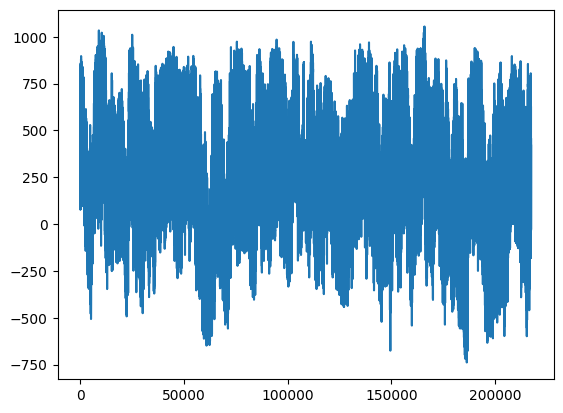

In [4]:
df.avg_flow_MW.plot()

In [5]:
df['hour_bucket'] = (
    df['datetime'] + pd.Timedelta(minutes=30)
).dt.floor('h')

df_hourly_hvdc = (
    df
    .groupby('hour_bucket')
    .agg(
        datetime_utc12      = ('datetime',      'max'),
        avg_flow_MW         = ('avg_flow_MW',   'mean'),
        peak_flow_MW        = ('peak_flow_MW',  lambda x: x.loc[x.abs().idxmax()]),
    )
    .reset_index(drop=True)
    .sort_values('datetime_utc12')
    .reset_index(drop=True)
)

# Derive direction from sign of avg_flow
df_hourly_hvdc['Direction'] = df_hourly_hvdc['avg_flow_MW'].map(
    lambda x: 'Northward at Haywards' if x > 0 else ('Southward at Benmore' if x < 0 else '0')
)

In [6]:
df_hourly_hvdc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108674 entries, 0 to 108673
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   datetime_utc12  108674 non-null  datetime64[ns]
 1   avg_flow_MW     108674 non-null  float64       
 2   peak_flow_MW    108674 non-null  float64       
 3   Direction       108674 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.3+ MB


In [7]:
df_hourly_hvdc.head()


,datetime_utc12,avg_flow_MW,peak_flow_MW,Direction
0,2013-12-31 23:00:00,445.0,445.0,Northward at Haywards
1,2014-01-01 00:00:00,373.0,386.0,Northward at Haywards
2,2014-01-01 01:00:00,366.0,367.0,Northward at Haywards
3,2014-01-01 02:00:00,326.0,328.0,Northward at Haywards
4,2014-01-01 03:00:00,293.5,319.0,Northward at Haywards


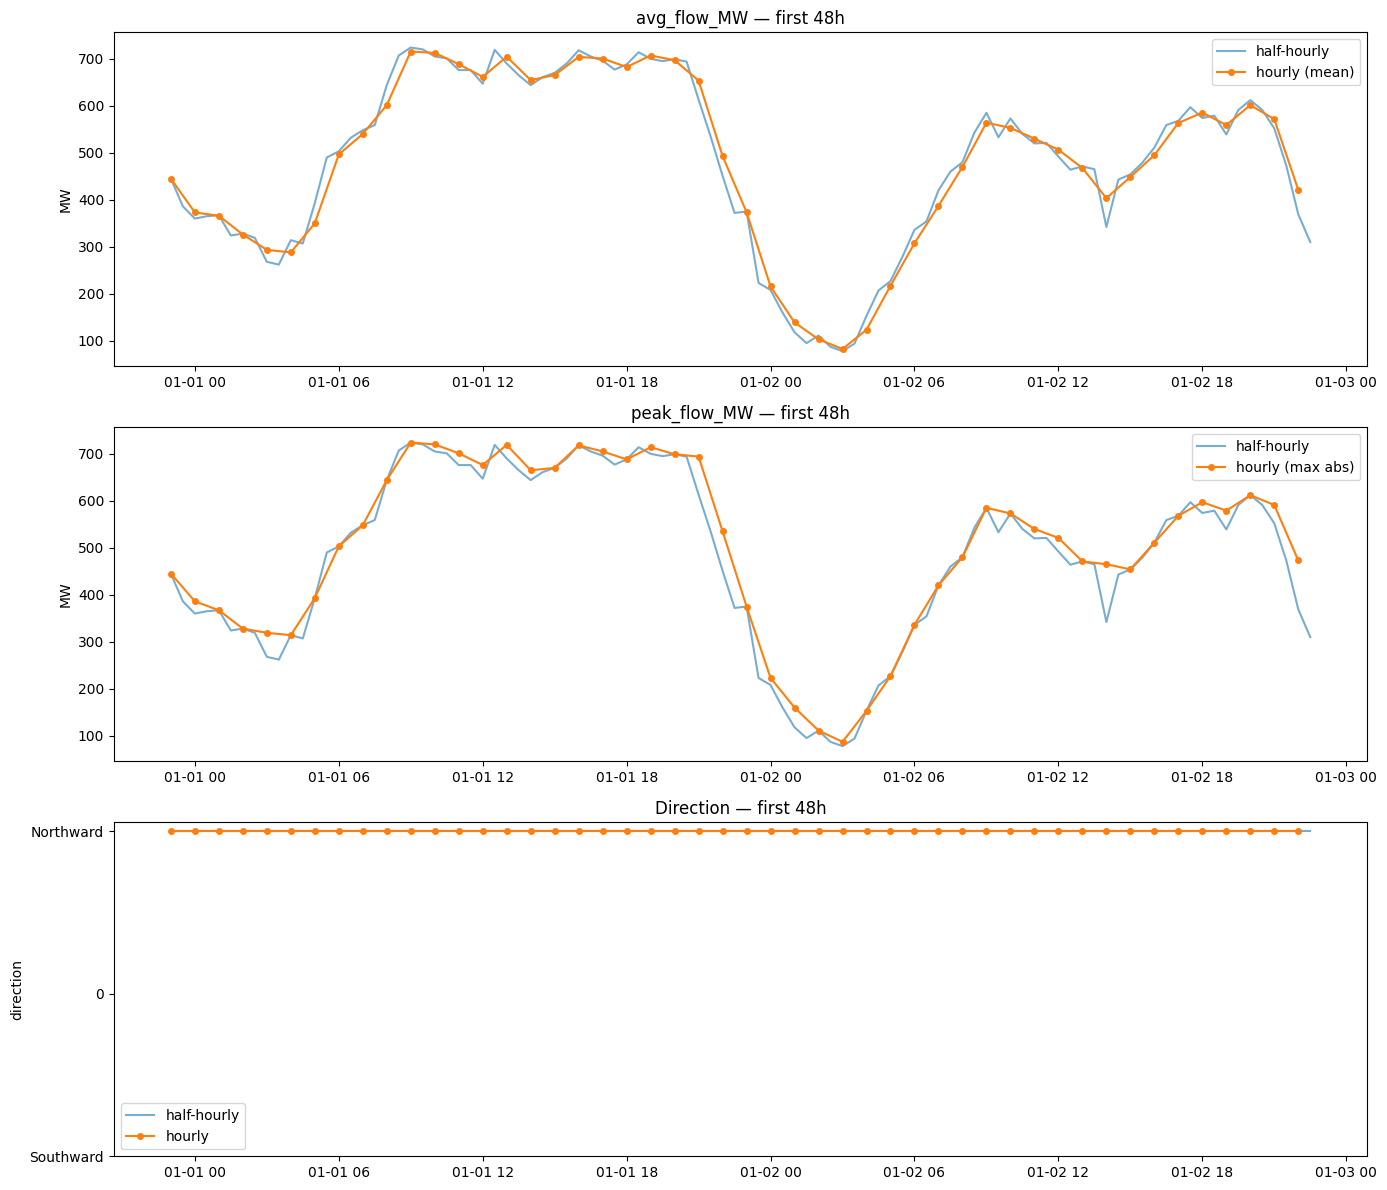

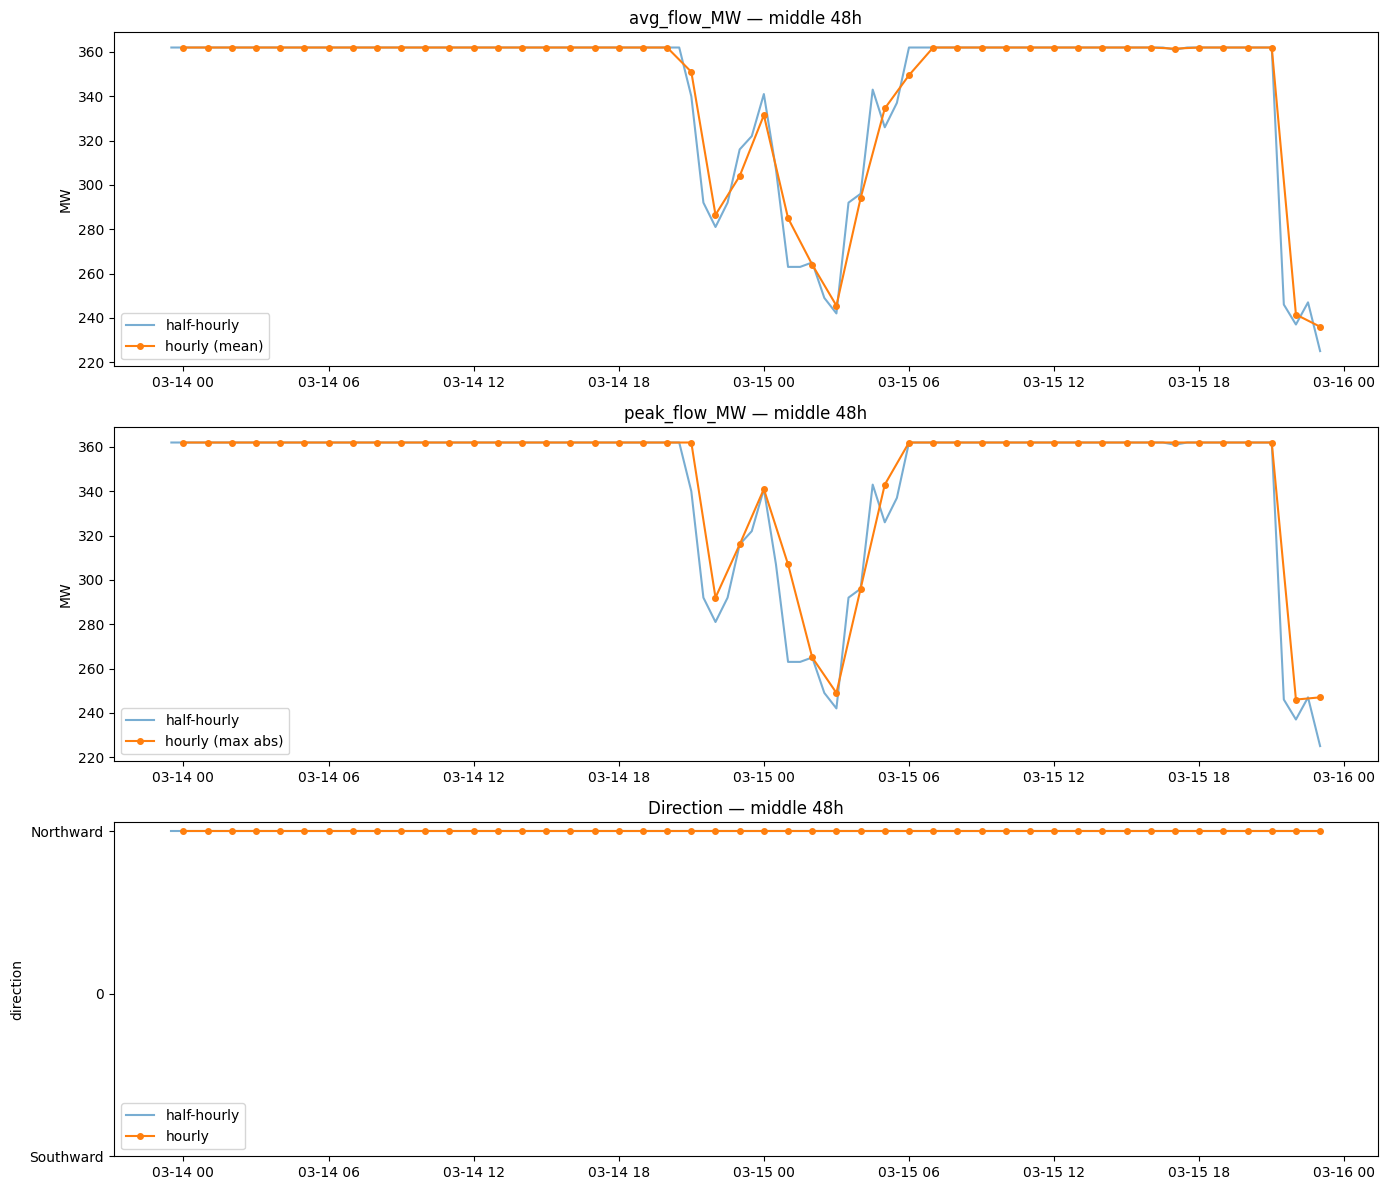

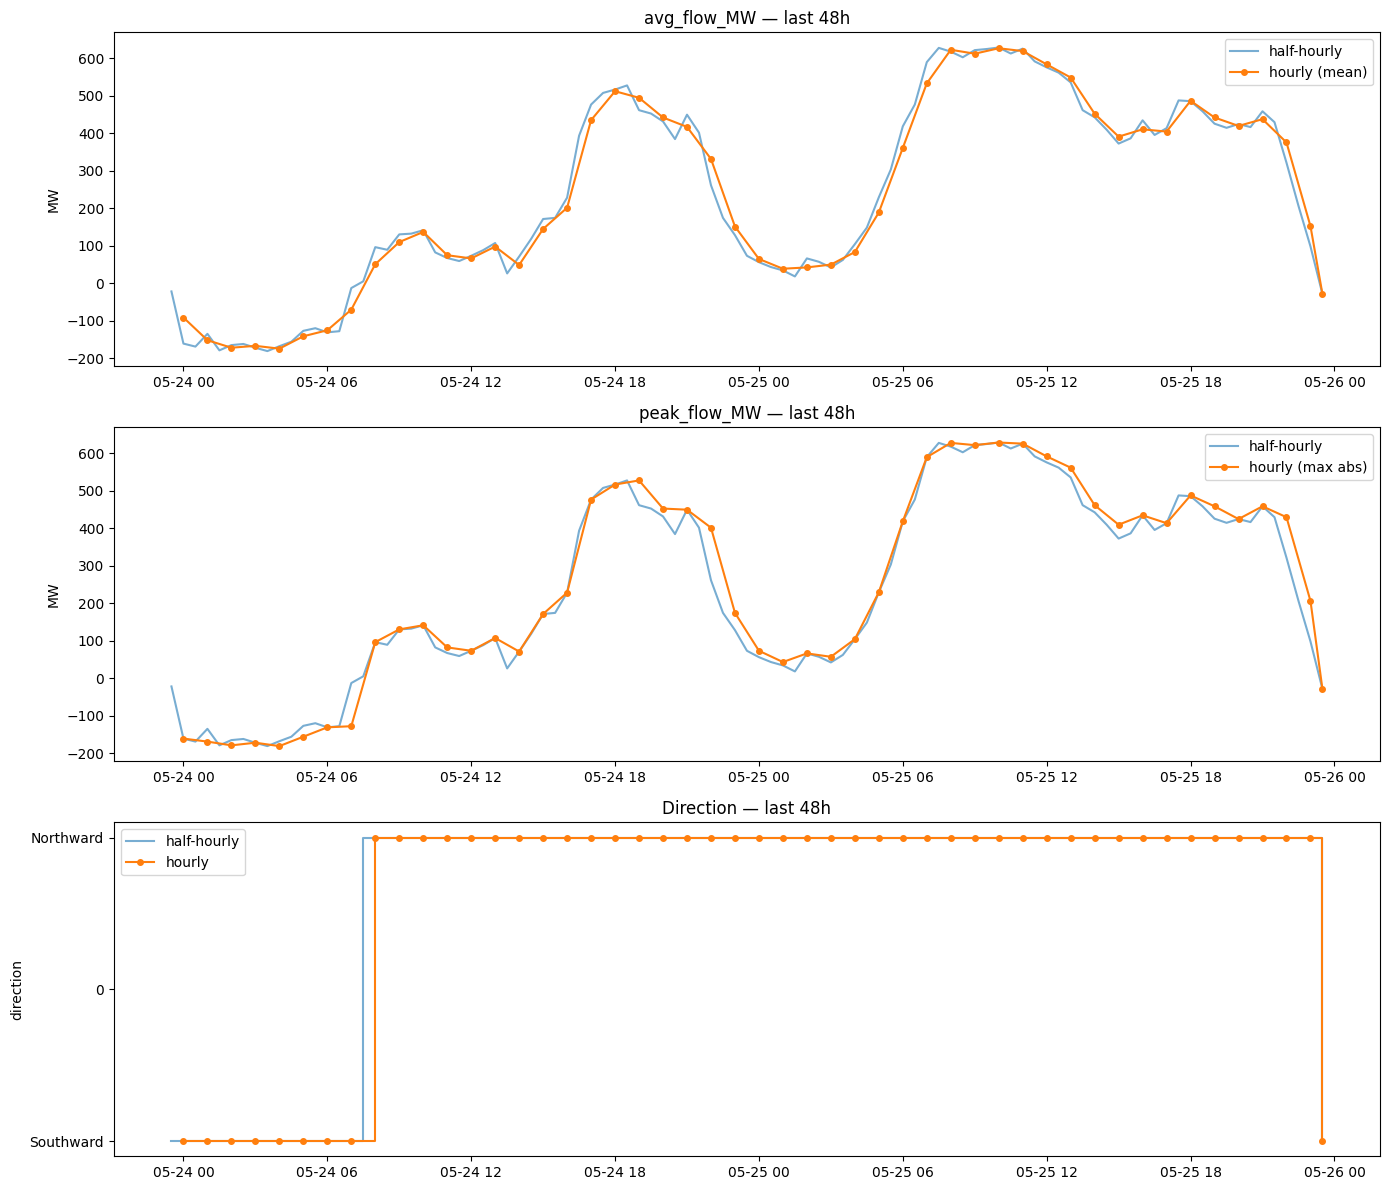

In [8]:
import matplotlib.pyplot as plt

def plot_window_hvdc(label, mask_hh, mask_h):
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

    # avg_flow_MW
    axes[0].plot(df[mask_hh]['datetime'], df[mask_hh]['avg_flow_MW'], label='half-hourly', alpha=0.6)
    axes[0].plot(df_hourly_hvdc[mask_h]['datetime_utc12'], df_hourly_hvdc[mask_h]['avg_flow_MW'], label='hourly (mean)', marker='o', markersize=4)
    axes[0].set_title(f'avg_flow_MW — {label}')
    axes[0].set_ylabel('MW')
    axes[0].legend()

    # peak_flow_MW
    axes[1].plot(df[mask_hh]['datetime'], df[mask_hh]['peak_flow_MW'], label='half-hourly', alpha=0.6)
    axes[1].plot(df_hourly_hvdc[mask_h]['datetime_utc12'], df_hourly_hvdc[mask_h]['peak_flow_MW'], label='hourly (max abs)', marker='o', markersize=4)
    axes[1].set_title(f'peak_flow_MW — {label}')
    axes[1].set_ylabel('MW')
    axes[1].legend()

    # Direction
    direction_map = {'Northward at Haywards': 1, 'Southward at Benmore': -1, '0': 0}
    dir_hh = df[mask_hh]['Direction'].map(direction_map)
    dir_h  = df_hourly_hvdc[mask_h]['Direction'].map(direction_map)

    axes[2].step(df[mask_hh]['datetime'], dir_hh, label='half-hourly', alpha=0.6, where='post')
    axes[2].step(df_hourly_hvdc[mask_h]['datetime_utc12'], dir_h, label='hourly', marker='o', markersize=4, where='post')
    axes[2].set_title(f'Direction — {label}')
    axes[2].set_ylabel('direction')
    axes[2].set_yticks([-1, 0, 1])
    axes[2].set_yticklabels(['Southward', '0', 'Northward'])
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# First 48h
mask_hh_start = df['datetime'] < df['datetime'].min() + pd.Timedelta(hours=48)
mask_h_start  = df_hourly_hvdc['datetime_utc12'] < df_hourly_hvdc['datetime_utc12'].min() + pd.Timedelta(hours=48)

# Middle
mid_hh = df['datetime'].min() + (df['datetime'].max() - df['datetime'].min()) / 2
mid_h  = df_hourly_hvdc['datetime_utc12'].min() + (df_hourly_hvdc['datetime_utc12'].max() - df_hourly_hvdc['datetime_utc12'].min()) / 2

mask_hh_mid = (df['datetime'] >= mid_hh) & (df['datetime'] < mid_hh + pd.Timedelta(hours=48))
mask_h_mid  = (df_hourly_hvdc['datetime_utc12'] >= mid_h) & (df_hourly_hvdc['datetime_utc12'] < mid_h + pd.Timedelta(hours=48))

# End
mask_hh_end = df['datetime'] >= df['datetime'].max() - pd.Timedelta(hours=48)
mask_h_end  = df_hourly_hvdc['datetime_utc12'] >= df_hourly_hvdc['datetime_utc12'].max() - pd.Timedelta(hours=48)

plot_window_hvdc('first 48h',  mask_hh_start, mask_h_start)
plot_window_hvdc('middle 48h', mask_hh_mid,   mask_h_mid)
plot_window_hvdc('last 48h',   mask_hh_end,   mask_h_end)